## 2. Data Preparation

In this notebook we will prepare the data for machine learning:
- download card images
- resize to 120x168 RGB (width x height)
- map the rarities to 5 classes
- handle class imbalance 
- one-hot encode labels
- save prepared data to disk
- normalize and split data

In [ ]:
import sys
sys.path.insert(0, '..')

from data.dataset import Dataset
from data.rarity_classes import RARITY_CLASSES
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


/Users/markusgarmeister/Desktop/ML_PokeCard/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/markusgarmeister/Desktop/ML_PokeCard/notebooks


## 2.1 Load mapped data

First we load the data with our mapped rarity. In the dataset are about ~300 cards, which have no rarity label. In addition we haven't mapped the promo cards, because they come in all forms of rarities. Therefore I decided to neglect them, since it just a small part of the over 18,000 cards. This leaves us with a dataset of 16731 cards.

Total cards in dataset with rarity label: 16731

Class distribution:
mapped_rarity
Common         4632
Uncommon       4407
Rare           4005
Ultra Rare     2328
Secret Rare    1359
Name: count, dtype: int64


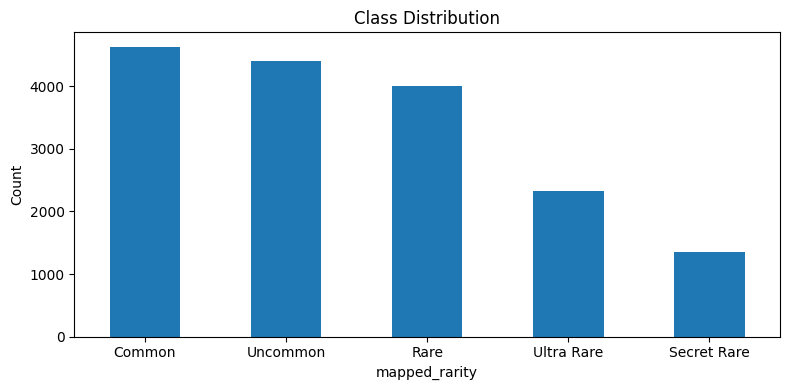

In [2]:
dataset = Dataset()
df = dataset.get_mapped_dataset()
df = df[df['mapped_rarity'].notna()]
print(f"Total cards in dataset with rarity label: {len(df)}")
print(f"\nClass distribution:")
print(df['mapped_rarity'].value_counts())

df['mapped_rarity'].value_counts().plot(kind='bar', figsize=(8, 4))           
plt.xticks(rotation=0)                                                        
plt.title('Class Distribution')                                               
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 2.2 Undersampling and Download Images

Even though we mapped the rarity labels, our classes are not balanced. Ultra rares are about the half of rares and Secret rares about a third of rares. Instead of duplicating the data of the less represented classes (oversampling), I decided to undersample the classes to 500 images per class, because first of all the model should see each class the same amount, in order to prevent the model to be biased towards Common, Uncommon and Rare cards. The second reason for undersampling is to make the training process faster. Also I'm limited in hardware, therefore I wasn't able to use all images. Therefore I also resize the images to 168x120 RGB, when downloading the images. This reduces the amount of pixel to a fourth of the original size 342x245 and makes training faster. However this makes training harder in terms of recognizing the rarity symbols on the bottom.

In [ ]:
MAX_PER_CLASS = 500
balanced_df = df.groupby('mapped_rarity').apply(lambda x: x.sample(MAX_PER_CLASS, random_state=42))
x_images, y_labels, failed = dataset.download_images(balanced_df)
print(f"\nSuccessfully loaded: {len(x_images)} images")
print(f"Failed downloads: {failed}")
print(f"\nClass distribution after undersampling:")
print(pd.Series(y_labels).value_counts())

/var/folders/sk/rs8l7jb53ms_qdt354_4brmm0000gn/T/ipykernel_14264/1211004854.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby('mapped_rarity').apply(lambda x: x.sample(MAX_PER_CLASS))


https://images.pokemontcg.io/sv7/35.png
https://images.pokemontcg.io/swsh8/172.png
https://images.pokemontcg.io/xy7/62.png
https://images.pokemontcg.io/swsh9/84.png
https://images.pokemontcg.io/gym1/64.png
https://images.pokemontcg.io/swsh8/205.png
https://images.pokemontcg.io/swsh9/110.png
https://images.pokemontcg.io/sv2/44.png
https://images.pokemontcg.io/dp5/56.png
https://images.pokemontcg.io/xy11/38.png
https://images.pokemontcg.io/bw6/72.png
https://images.pokemontcg.io/swsh1/125.png
https://images.pokemontcg.io/sm12/54.png
https://images.pokemontcg.io/col1/53.png
https://images.pokemontcg.io/xy5/4.png
https://images.pokemontcg.io/dp5/90.png
https://images.pokemontcg.io/sv4pt5/18.png
https://images.pokemontcg.io/swsh7/71.png
https://images.pokemontcg.io/ecard3/82.png
https://images.pokemontcg.io/dp6/99.png
https://images.pokemontcg.io/g1/16.png
https://images.pokemontcg.io/neo4/71.png
https://images.pokemontcg.io/pop4/11.png
https://images.pokemontcg.io/sv7/81.png
https://images

## 2.3 One-hot encode

I'm converting the images to an numpy array and one-hot encode the 5 rarity classes.
- [1, 0, 0, 0, 0] -> Common
- [0, 1, 0, 0, 0] -> Uncommon
- [0, 0, 1, 0, 0] -> Rare
- [0, 0, 0, 1, 0] -> Ultra Rare
- [0, 0, 0, 0, 1] -> Secret Rare

In [10]:
# Convert images to numpy array
X = np.array(x_images)
print(X.shape)

# One-hot encode labels
label_to_idx = {label: idx for idx, label in enumerate(RARITY_CLASSES)}
y_indices = np.array([label_to_idx[label] for label in y_labels])
y = np.eye(len(RARITY_CLASSES))[y_indices]
print(f"y shape: {y.shape}")  # (N, 5)

print(f"\nLabel encoding:")
for label, idx in label_to_idx.items():
    print(f"  {idx}: {label}")
 

(2500, 168, 120, 3)
y shape: (2500, 5)

Label encoding:
  0: Common
  1: Uncommon
  2: Rare
  3: Ultra Rare
  4: Secret Rare


## 2.4 Storing Data 

I'm storing the data to disk. The images and the one hot encoded rarity classs will be stored as numpy array under /data/dataset/  

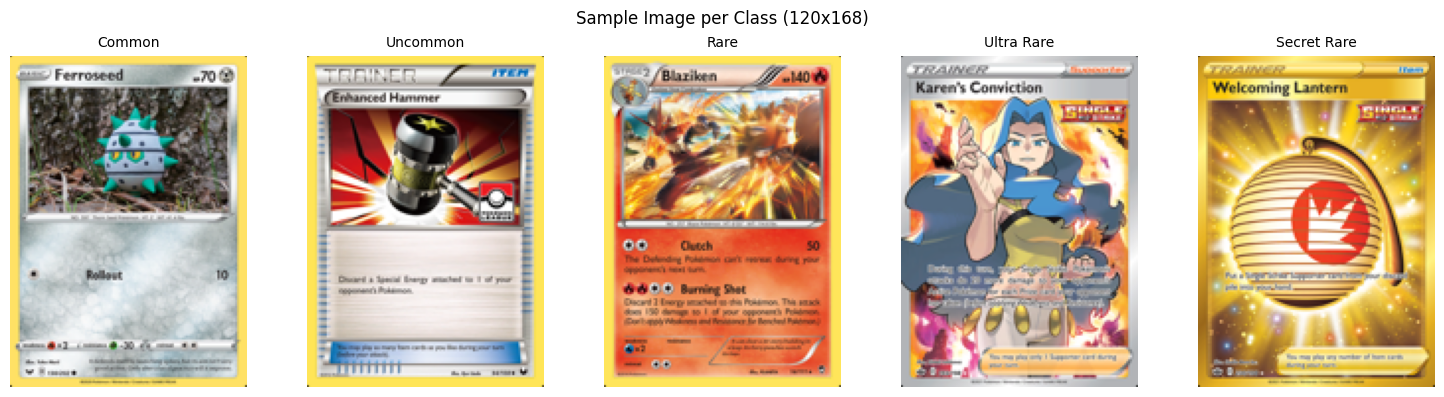

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i, cls in enumerate(RARITY_CLASSES):
    idx = np.where(y_indices == i)[0][0]
    axes[i].imshow(X[idx])
    axes[i].set_title(cls, fontsize=10)
    axes[i].axis('off')
plt.suptitle('Sample Image per Class (120x168)', fontsize=12)
plt.tight_layout()
plt.show()

#store prep data
dataset.store_prep_data(X, y)

## 2.5 Normalization and Splitting

With the Dataset.get_train_val_test_split() method. I split the data into 70% training, 15% validation and 15% test data. The split is evenly distributed by class. So every class is split into 350/75/75 cards. I added the validation set for early stopping. In addition this method also normalizes our image vectors, so training is possible and stable.

In [11]:
X_train, X_val, X_test, y_train, y_val, y_test = dataset.get_train_val_test_split()
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")                                                                           
print(f"Per-class in train: {y_train.sum(axis=0).astype(int)}")
print(f"Per-class in val:   {y_val.sum(axis=0).astype(int)}")                                                                                                 
print(f"Per-class in test:  {y_test.sum(axis=0).astype(int)}")                                                                                                
print(f"X_train dtype: {X_train.dtype}, range: [{X_train.min():.2f}, {X_train.max():.2f}]")  

Train: 1750, Val: 375, Test: 375
Per-class in train: [350 350 350 350 350]
Per-class in val:   [75 75 75 75 75]
Per-class in test:  [75 75 75 75 75]
X_train dtype: float32, range: [0.00, 1.00]


## 2.6 Summary

- Downloaded 2500 card images ( 500 per class)
- Resized all images to 120x168 RGB
- One-hot encoded 5 rarity classes 
- Saved prepared data as .npy file in /data/dataset
- Splitting each class into training, validation and test (350/75/75 cards)